# **Version 1 using regression and trees on limited features!**

In [2]:
train = pd.read_csv('/content/train.csv')
test = pd.read_csv('/content/test.csv')

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
train.shape

(1460, 81)

In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [6]:
train["SalePrice"].head()

,SalePrice
0,208500
1,181500
2,223500
3,140000
4,250000


In [7]:
missing = train.isnull().sum()

missing = missing[missing > 0]

missing.sort_values(ascending=False)

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageType,81
GarageYrBlt,81
GarageFinish,81


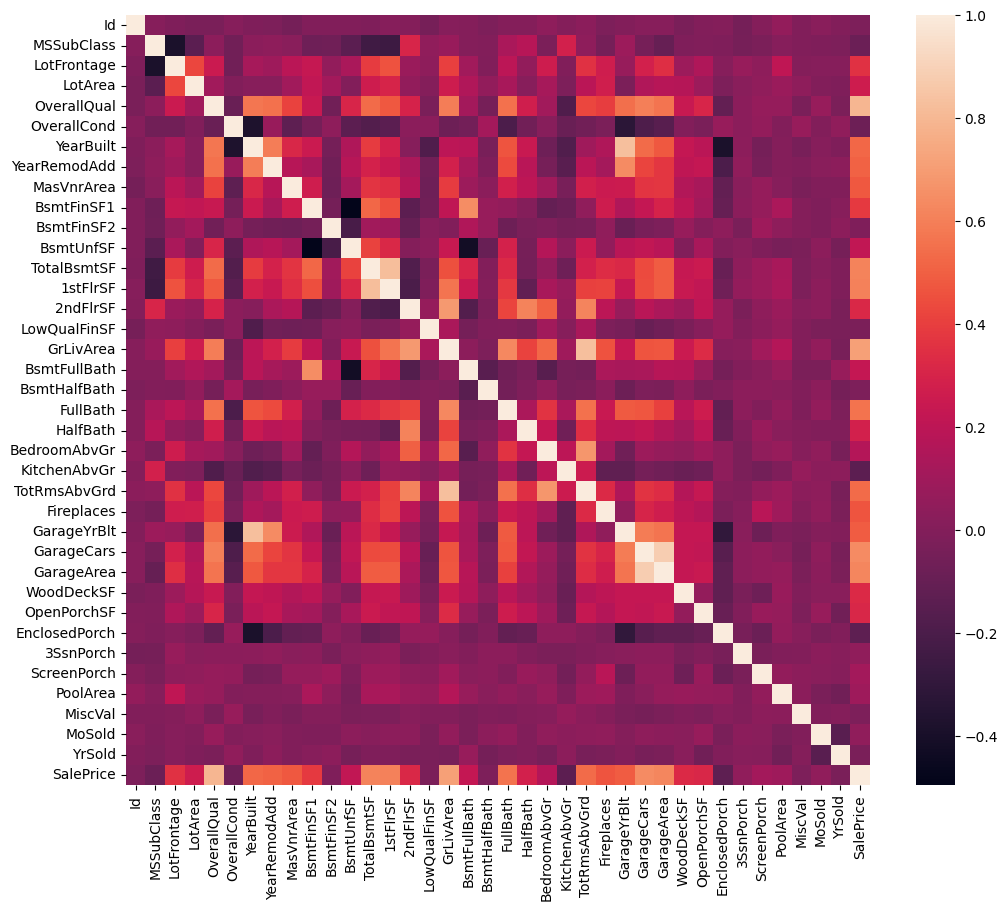

In [8]:
corr = train.corr(numeric_only=True)

plt.figure(figsize=(12,10))
sns.heatmap(corr)
plt.show()

In [9]:
corr["SalePrice"].sort_values(ascending=False)

,SalePrice
SalePrice,1.000000
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897


In [10]:
features = [
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "GarageArea",
    "TotalBsmtSF",
    "FullBath",
    "YearBuilt"
]

In [11]:
X = train[features]

y = train["SalePrice"]

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:
from sklearn.ensemble import RandomForestRegressor

In [14]:
model = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=300, random_state=42)

In [15]:
predictions = model.predict(X_valid)

In [16]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(
    y_valid,
    predictions
)

print(mae)

19432.216827000433


In [17]:
from xgboost import XGBRegressor

In [18]:
xgb = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=4,
    random_state=42
)

xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

In [19]:
import pandas as pd

train = pd.read_csv('/content/train.csv')

print(train.shape)
print("\n")

print(train.head())

(1460, 81)


   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008

In [20]:
from sklearn.metrics import r2_score

r2 = r2_score(y_valid, predictions)

print("R2 Score:", r2)

R2 Score: 0.881611506230685


In [21]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
})

importance.sort_values(
    by='Importance',
    ascending=False
)

,Feature,Importance
0,OverallQual,0.580797
1,GrLivArea,0.186962
4,TotalBsmtSF,0.102470
6,YearBuilt,0.050751
3,GarageArea,0.042487
2,GarageCars,0.023692
5,FullBath,0.012840


In [22]:
print(train.isnull().sum().sort_values(ascending=False).head(20))

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
Condition2         0
dtype: int64


In [23]:
print(train.dtypes.value_counts())

object     43
int64      35
float64     3
Name: count, dtype: int64


In [24]:
print("R2 =", r2_score(y_valid, predictions))

R2 = 0.881611506230685


# **Version 2**

#### Raw Data → Missing Value Handling → Convert Text → Numbers → Train Model → Evaluate

##### Data → Cleaning → Encoding → Model

In [25]:
from sklearn.model_selection import train_test_split

X = train.drop("SalePrice", axis=1)
y = train["SalePrice"]

In [26]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

In [27]:
numeric_features = X.select_dtypes(
    include=['int64','float64']
).columns

categorical_features = X.select_dtypes(
    include=['object']
).columns

In [28]:
numeric_transformer = Pipeline(
    steps=[
        ('imputer',
         SimpleImputer(strategy='median'))
    ]
)

In [29]:
categorical_transformer = Pipeline(
    steps=[
        ('imputer',
         SimpleImputer(
             strategy='constant',
             fill_value='Missing'
         )),
        ('onehot',
         OneHotEncoder(
             handle_unknown='ignore'
         ))
    ]
)

In [30]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            numeric_transformer,
            numeric_features
        ),
        (
            'cat',
            categorical_transformer,
            categorical_features
        )
    ]
)

In [32]:
from xgboost import XGBRegressor

In [33]:
model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=4,
    random_state=42
)

In [34]:
pipeline = Pipeline(
    steps=[
        ('preprocessor',
         preprocessor),
        ('model',
         model)
    ]
)

In [35]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [36]:
pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.03,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=4, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=1000, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [37]:
preds = pipeline.predict(X_valid)

In [38]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

print(
    "MAE:",
    mean_absolute_error(
        y_valid,
        preds
    )
)

print(
    "R2:",
    r2_score(
        y_valid,
        preds
    )
)

MAE: 15790.125
R2: 0.9172783493995667


# **Where did my model failed?**

In [39]:
import pandas as pd

results = pd.DataFrame({
    "Actual": y_valid,
    "Predicted": preds
})

results["Error"] = abs(
    results["Actual"] -
    results["Predicted"]
)

results.sort_values(
    by="Error",
    ascending=False
).head(20)

,Actual,Predicted,Error
691,755000,587350.625000,167649.375000
581,253293,378541.593750,125248.593750
774,395000,280785.937500,114214.062500
898,611657,519749.093750,91907.906250
1046,556581,468811.562500,87769.437500
261,276000,360292.687500,84292.687500
218,311500,229980.921875,81519.078125
588,143000,219707.250000,76707.250000
1024,287000,360297.968750,73297.968750
1243,465000,406330.937500,58669.062500


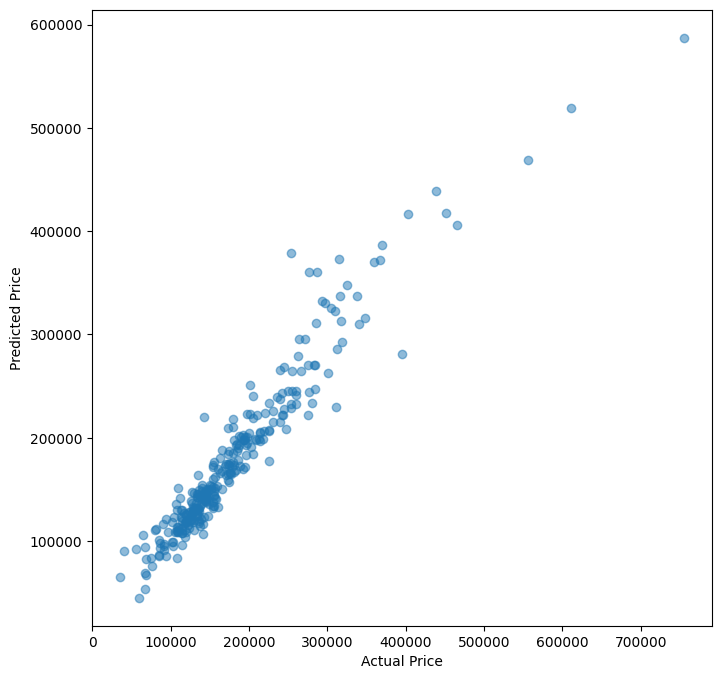

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

plt.scatter(
    y_valid,
    preds,
    alpha=0.5
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.show()

# **Creating Features**

In [41]:
train["HouseAge"] = (
    train["YrSold"]
    - train["YearBuilt"]
)

train["TotalBathrooms"] = (
    train["FullBath"]
    + 0.5 * train["HalfBath"]
    + train["BsmtFullBath"]
    + 0.5 * train["BsmtHalfBath"]
)

train["TotalSF"] = (
    train["TotalBsmtSF"]
    + train["1stFlrSF"]
    + train["2ndFlrSF"]
)

In [42]:
import joblib

joblib.dump(
    pipeline,
    "house_price_model.pkl"
)

['house_price_model.pkl']

# **Now here comes the testing time!**

In [43]:
test = pd.read_csv(
    "/content/test.csv"
)

In [44]:
test_preds = pipeline.predict(test)

In [45]:
submission = pd.DataFrame({
    "Id": test["Id"],
    "SalePrice": test_preds
})

In [46]:
submission.to_csv(
    "submission.csv",
    index=False
)

In [47]:
pipeline.named_steps['model']

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

# **Testing things to increase ^_^**

In [48]:
for df in [train, test]:

    df["HouseAge"] = df["YrSold"] - df["YearBuilt"]

    df["TotalBathrooms"] = (
        df["FullBath"]
        + 0.5 * df["HalfBath"]
        + df["BsmtFullBath"]
        + 0.5 * df["BsmtHalfBath"]
    )

    df["TotalSF"] = (
        df["TotalBsmtSF"]
        + df["1stFlrSF"]
        + df["2ndFlrSF"]
    )

In [56]:
y = np.log1p(train["SalePrice"])

In [57]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [58]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.03,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=4, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=1000, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [59]:
preds_log = pipeline.predict(X_valid)

In [60]:
import numpy as np

preds = np.expm1(preds_log)
actual = np.expm1(y_valid)

In [61]:
from sklearn.metrics import mean_absolute_error, r2_score

print("MAE =", mean_absolute_error(actual, preds))
print("R2 =", r2_score(actual, preds))

MAE = 16183.890156785119
R2 = 0.9052330687367804


In [62]:
print(X.shape)
print(y.shape)

(1460, 80)
(1460,)
